In [1]:
#mport the liberaries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    MinMaxScaler, StandardScaler, RobustScaler,
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Adult,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Adult,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Adult,Mr


Shape: (891, 14)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
 12  AgeGroup     714 non-null    str    
 13  Title        891 non-null    str    
dtypes: float64(2), int64(5), str(7)
memory usage: 97.6 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Title
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891,891,714,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,148,3,4,17
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,Unknown,S,Adult,Mr
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,687,646,553,517
mean,446.000000,0.383838,2.308642,NaN,NaN,29.361582,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.019697,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN,NaN


,Missing Count,Missing %
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,0,0.00
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


Duplicates: 0

Name
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

Sex
Sex
male      577
female    314
Name: count, dtype: int64

Ticket
Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1


C:\Users\user\AppData\Local\Temp\ipykernel_31004\2040194843.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in titanic_workshop.select_dtypes(include="object"):


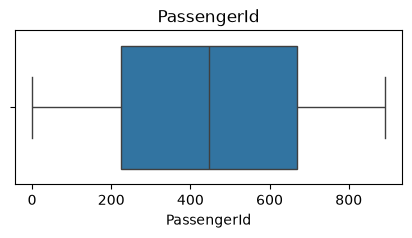

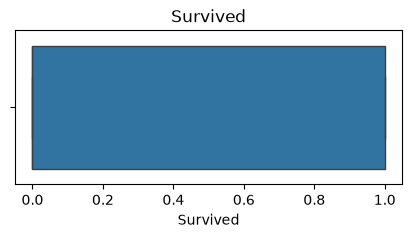

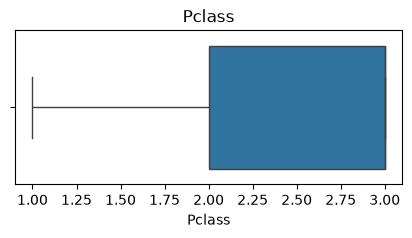

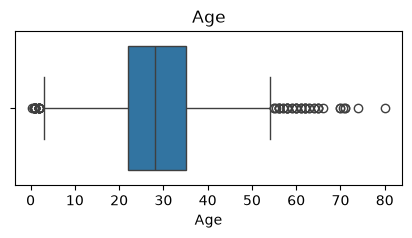

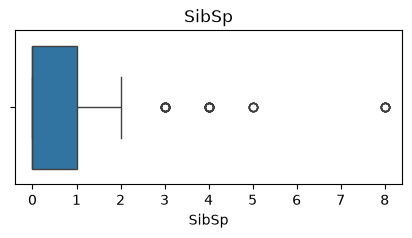

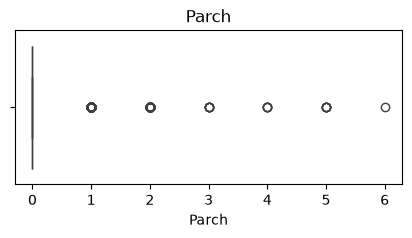

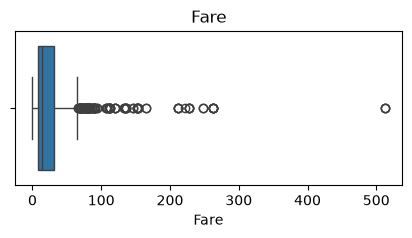

In [2]:
# Step 1: Assess Data Quality
titanic_workshop = pd.read_csv(r"D:\NTI-ML\nti-projects\titanic-survival-analysis\data\processed\titanic_cleaned.csv")

# Preview data
display(titanic_workshop.head())

# Check shape
print("Shape:", titanic_workshop.shape)

# Dataset info
titanic_workshop.info()

# Summary statistics
display(titanic_workshop.describe(include="all"))

# Missing values
missing = pd.DataFrame({
    "Missing Count": titanic_workshop.isnull().sum(),
    "Missing %": (titanic_workshop.isnull().mean() * 100).round(2)
})

display(missing)

# Duplicate rows
print("Duplicates:", titanic_workshop.duplicated().sum())

# Check unique values
for col in titanic_workshop.select_dtypes(include="object"):
    print(f"\n{col}")
    print(titanic_workshop[col].value_counts(dropna=False))

# Detect outliers
numeric_cols = titanic_workshop.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=titanic_workshop[col])
    plt.title(col)
    plt.show()


In [ ]:
# Step 2 — Clean the Dataset
# Fill missing Age
titanic_workshop["Age"] = titanic_workshop["Age"].fillna(
    titanic_workshop["Age"].median()
)

# Fill missing Embarked
titanic_workshop["Embarked"] = titanic_workshop["Embarked"].fillna(
    titanic_workshop["Embarked"].mode()[0]
)

# Drop Cabin
titanic_workshop.drop(columns="Cabin", inplace=True)

# Remove duplicates
titanic_workshop.drop_duplicates(inplace=True)

# Convert data types
titanic_workshop["Survived"] = titanic_workshop["Survived"].astype("category")
titanic_workshop["Pclass"] = titanic_workshop["Pclass"].astype("category")

# Handle Fare outliers
Q1 = titanic_workshop["Fare"].quantile(0.25)
Q3 = titanic_workshop["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

titanic_workshop["Fare"] = titanic_workshop["Fare"].clip(lower, upper)

In [ ]:
#Step 3 — Prepare Features
# Label Encoding
le = LabelEncoder()

titanic_workshop["Sex"] = le.fit_transform(titanic_workshop["Sex"])

# One-Hot Encoding
titanic_workshop = pd.get_dummies(
    titanic_workshop,
    columns=["Embarked"],
    drop_first=True
)

# Scale numerical feature
scaler = StandardScaler()

titanic_workshop["Age"] = scaler.fit_transform(
    titanic_workshop[["Age"]]
)

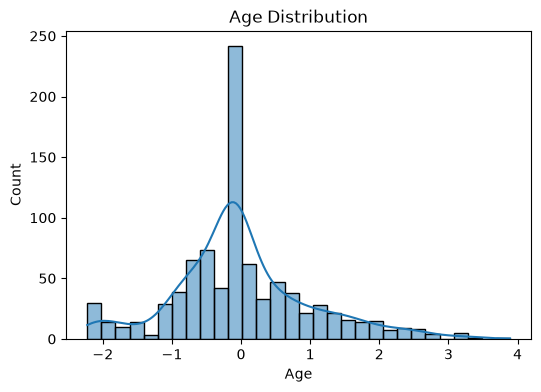

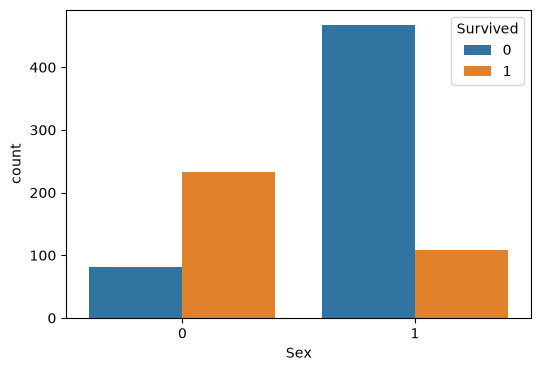

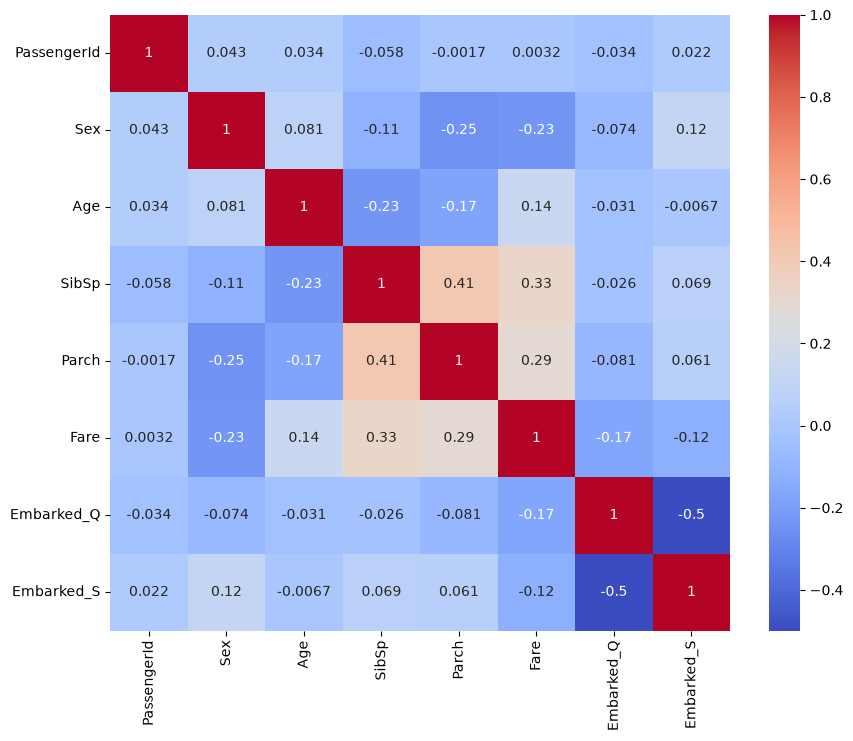

In [5]:
# Step 4 — Perform EDA
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(titanic_workshop["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Survival by sex
plt.figure(figsize=(6,4))
sns.countplot(data=titanic_workshop, x="Sex", hue="Survived")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    titanic_workshop.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [6]:
# Step 5 — Feature Engineering
# Family size
titanic_workshop["FamilySize"] = (
    titanic_workshop["SibSp"] +
    titanic_workshop["Parch"] + 1
)

# Is alone
titanic_workshop["IsAlone"] = (
    titanic_workshop["FamilySize"] == 1
).astype(int)

# Age group
titanic_workshop["AgeGroup"] = pd.cut(
    titanic_workshop["Age"],
    bins=[-5, -0.5, 0, 0.5, 5],
    labels=["Child", "Young", "Adult", "Senior"]
)

1. Filling missing values in Age had the biggest impact because many models cannot handle missing data.

2. The survival by sex chart was the most informative because it clearly showed the difference in survival rates.

3. FamilySize and IsAlone are likely to improve model performance because they capture social relationships.